## Supplemental Figure 5

- Cross-validation results (Supplemental Figure 5a-d) for linear interaction models (reference-based and reference-free frameworks with and without global epistasis inference/transformation)

- Comparison of optimal model performances by ordinary least-squares cross-validation (Supplemental Figure 5e)

- Comparison of significant coefficients (by bonferroni-corrected p-values) from optimal models (Supplemental Figure 5f)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FixedLocator
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

**Supplemental Figure 5a-d**

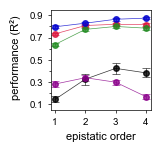

Saved: S_Figure_5a.png


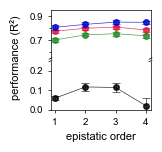

Saved: S_Figure_5b.png


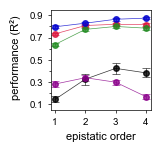

Saved: S_Figure_5c.png


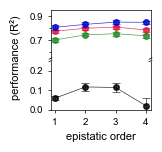

Saved: S_Figure_5d.png


In [2]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

LINEWIDTH = 0.5

MAJOR_TICK_WID = 0.5
MINOR_TICK_WID = 0.5
MAJOR_TICK_LEN = 2
MINOR_TICK_LEN = 1.5

LABEL_FONTSIZE = 8
TICK_LABEL_FONTSIZE = 7

CANVAS_WIDTH  = 1.0
CANVAS_HEIGHT = 1.0

LEFT_MARGIN   = 0.6
RIGHT_MARGIN  = 0.2
TOP_MARGIN    = 0.2
BOTTOM_MARGIN = 0.5

YAXIS_CONFIGS = {
    'biochem': {
        'broken': False,
        'ylim':         (0.05, 0.95),
        'major':        [0.1, 0.3, 0.5, 0.7, 0.9],
        'minor':        [0.2, 0.4, 0.6, 0.8],
    },
    'biochem_global': {
        'broken': True,
        'top_ylim':     (0.55, 0.95),
        'top_major':    [0.7, 0.9],
        'top_minor':    [0.6, 0.8],
        'bottom_ylim':  (0.0, 0.25),
        'bottom_major': [0.0, 0.1, 0.2],
        'bottom_minor': [],
    },
    'statistical': {
        'broken': False,
        'ylim':         (0.05, 0.95),
        'major':        [0.1, 0.3, 0.5, 0.7, 0.9],
        'minor':        [0.2, 0.4, 0.6, 0.8],
    },
    'statistical_global': {
        'broken': True,
        'top_ylim':     (0.55, 0.95),
        'top_major':    [0.7, 0.9],
        'top_minor':    [0.6, 0.8],
        'bottom_ylim':  (0.0, 0.25),
        'bottom_major': [0.0, 0.1, 0.2],
        'bottom_minor': [],
    },
}

COLOR_WUHAN = "#DC143C"
COLOR_BA1   = "#228B22"
COLOR_BA4   = "#0000CD"
COLOR_EXPR  = "#000000"
COLOR_PSR   = "#8b008b"

phenotype_colors = {
    'Wuhan':           COLOR_WUHAN,
    'BA.1':            COLOR_BA1,
    'BA.4':            COLOR_BA4,
    'expression':      COLOR_EXPR,
    'polyspecificity': COLOR_PSR,
}

phenotype_order = ['Wuhan', 'BA.1', 'BA.4', 'expression', 'polyspecificity']

plot_configs = {
    'biochem': {
        'title':    'reference-based',
        'filename': 'S_Figure_5a.png',
        'phenotypes': {
            'Wuhan':           {'path': '../../epistasis_inference/linear_interaction_models/wuhan/reference-based/find_best_order_CVs/CV_summaries/wuhan_globalep_model_comparison.csv',           'phenotype_name': 'raw', 'max_order': 4},
            'BA.1':            {'path': '../../epistasis_inference/linear_interaction_models/ba1/reference-based/find_best_order_CVs/CV_summaries/ba1_globalep_model_comparison.csv',               'phenotype_name': 'raw', 'max_order': 4},
            'BA.4':            {'path': '../../epistasis_inference/linear_interaction_models/ba4/reference-based/find_best_order_CVs/CV_summaries/ba4_globalep_model_comparison.csv',               'phenotype_name': 'raw', 'max_order': 4},
            'expression':      {'path': '../../epistasis_inference/linear_interaction_models/expression/reference-based/find_best_order_CVs/CV_summaries/expression_globalep_model_comparison.csv', 'phenotype_name': 'raw', 'max_order': 4},
            'polyspecificity': {'path': '../../epistasis_inference/linear_interaction_models/psr/reference-based/find_best_order_CVs/CV_summaries/psr_globalep_model_comparison.csv',               'phenotype_name': 'raw', 'max_order': 4},
        },
    },
    'biochem_global': {
        'title':    'reference-based + nonlinear transformation',
        'filename': 'S_Figure_5b.png',
        'phenotypes': {
            'Wuhan':           {'path': '../../epistasis_inference/linear_interaction_models/wuhan/reference-based/find_best_order_CVs/CV_summaries/wuhan_globalep_model_comparison.csv',           'phenotype_name': 'latent_hill_v1',     'max_order': 4},
            'BA.1':            {'path': '../../epistasis_inference/linear_interaction_models/ba1/reference-based/find_best_order_CVs/CV_summaries/ba1_globalep_model_comparison.csv',               'phenotype_name': 'latent_hill_v1',     'max_order': 4},
            'BA.4':            {'path': '../../epistasis_inference/linear_interaction_models/ba4/reference-based/find_best_order_CVs/CV_summaries/ba4_globalep_model_comparison.csv',               'phenotype_name': 'latent_hill_v1',     'max_order': 4},
            'expression':      {'path': '../../epistasis_inference/linear_interaction_models/expression/reference-based/find_best_order_CVs/CV_summaries/expression_globalep_model_comparison.csv', 'phenotype_name': 'latent_logistic_v1', 'max_order': 4},
            'polyspecificity': None,
        },
    },
    'statistical': {
        'title':    'reference-free',
        'filename': 'S_Figure_5c.png',
        'phenotypes': {
            'Wuhan':           {'path': '../../epistasis_inference/linear_interaction_models/wuhan/reference-free/find_best_order_CVs/CV_summaries/wuhan_globalep_model_comparison.csv',           'phenotype_name': 'raw', 'max_order': 4},
            'BA.1':            {'path': '../../epistasis_inference/linear_interaction_models/ba1/reference-free/find_best_order_CVs/CV_summaries/ba1_globalep_model_comparison.csv',               'phenotype_name': 'raw', 'max_order': 4},
            'BA.4':            {'path': '../../epistasis_inference/linear_interaction_models/ba4/reference-free/find_best_order_CVs/CV_summaries/ba4_globalep_model_comparison.csv',               'phenotype_name': 'raw', 'max_order': 4},
            'expression':      {'path': '../../epistasis_inference/linear_interaction_models/expression/reference-free/find_best_order_CVs/CV_summaries/expression_globalep_model_comparison.csv', 'phenotype_name': 'raw', 'max_order': 4},
            'polyspecificity': {'path': '../../epistasis_inference/linear_interaction_models/psr/reference-free/find_best_order_CVs/CV_summaries/psr_globalep_model_comparison.csv',               'phenotype_name': 'raw', 'max_order': 4},
        },
    },
    'statistical_global': {
        'title':    'reference-free + nonlinear transformation',
        'filename': 'S_Figure_5d.png',
        'phenotypes': {
            'Wuhan':           {'path': '../../epistasis_inference/linear_interaction_models/wuhan/reference-free/find_best_order_CVs/CV_summaries/wuhan_globalep_model_comparison.csv',           'phenotype_name': 'latent_hill_v1',     'max_order': 4},
            'BA.1':            {'path': '../../epistasis_inference/linear_interaction_models/ba1/reference-free/find_best_order_CVs/CV_summaries/ba1_globalep_model_comparison.csv',               'phenotype_name': 'latent_hill_v1',     'max_order': 4},
            'BA.4':            {'path': '../../epistasis_inference/linear_interaction_models/ba4/reference-free/find_best_order_CVs/CV_summaries/ba4_globalep_model_comparison.csv',               'phenotype_name': 'latent_hill_v1',     'max_order': 4},
            'expression':      {'path': '../../epistasis_inference/linear_interaction_models/expression/reference-free/find_best_order_CVs/CV_summaries/expression_globalep_model_comparison.csv', 'phenotype_name': 'latent_logistic_v1', 'max_order': 4},
            'polyspecificity': None,
        },
    },
}

def load_phenotype_data(cfg):
    df = pd.read_csv(cfg['path'])
    for col in ['order', 'r2_test_mean', 'r2_test_std']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[
        (df['phenotype_name'] == cfg['phenotype_name']) &
        (df['scope'] == 'all') &
        (df['order'] <= cfg['max_order'])
    ].copy()
    return df.sort_values('order')


def draw_lines(ax, d, color):
    ax.errorbar(
        d['order'],
        d['r2_test_mean'],
        yerr=d['r2_test_std'],
        fmt='-o',
        color=color,
        ecolor=color,
        linewidth=LINEWIDTH,
        elinewidth=LINEWIDTH,
        capsize=3,
        capthick=LINEWIDTH,
        markersize=4,
        alpha=0.8
    )

def make_plot(model_key):
    cfg   = plot_configs[model_key]
    ycfg  = YAXIS_CONFIGS[model_key]
    fname = cfg['filename']

    fig_width  = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
    fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

    fig = plt.figure(figsize=(fig_width, fig_height))

    loaded = {}
    all_orders = set()
    for phenotype in phenotype_order:
        pheno_cfg = cfg['phenotypes'].get(phenotype)
        if pheno_cfg is None:
            continue
        try:
            d = load_phenotype_data(pheno_cfg)
        except Exception as e:
            print(f"WARNING: could not load {phenotype} for {model_key}: {e}")
            continue
        if len(d) == 0:
            print(f"WARNING: no data found for {phenotype} in {model_key}")
            continue
        loaded[phenotype] = d
        all_orders.update(d['order'].tolist())

    orders = sorted(all_orders)

    if not ycfg['broken']:
        gs = GridSpec(1, 1, figure=fig,
                      left   = LEFT_MARGIN / fig_width,
                      right  = (LEFT_MARGIN + CANVAS_WIDTH) / fig_width,
                      top    = 1 - TOP_MARGIN / fig_height,
                      bottom = BOTTOM_MARGIN / fig_height)

        ax = fig.add_subplot(gs[0])
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(LINEWIDTH)

        ax.set_ylim(*ycfg['ylim'])
        ax.yaxis.set_major_locator(FixedLocator(ycfg['major']))
        ax.yaxis.set_minor_locator(FixedLocator(ycfg['minor']))
        ax.tick_params(axis='y', which='major',
                       width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                       direction='out', labelsize=TICK_LABEL_FONTSIZE)
        ax.tick_params(axis='y', which='minor',
                       width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
                       direction='out', labelleft=False)

        ax.set_xticks(orders)
        ax.set_xticklabels([str(int(o)) for o in orders],
                            fontsize=TICK_LABEL_FONTSIZE)
        ax.tick_params(axis='x', which='major',
                       width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                       direction='out', labelsize=TICK_LABEL_FONTSIZE)

        for phenotype, d in loaded.items():
            draw_lines(ax, d, phenotype_colors[phenotype])

        ax.set_xlabel('epistatic order', fontsize=LABEL_FONTSIZE)
        fig.text(LEFT_MARGIN / fig_width - 0.225, 0.6,
                 'performance (R²)',
                 fontsize=LABEL_FONTSIZE, va='center', rotation='vertical')

    else:
        gs = GridSpec(2, 1, figure=fig,
                      left   = LEFT_MARGIN / fig_width,
                      right  = (LEFT_MARGIN + CANVAS_WIDTH) / fig_width,
                      top    = 1 - TOP_MARGIN / fig_height,
                      bottom = BOTTOM_MARGIN / fig_height,
                      hspace = 0.05,
                      height_ratios=[1, 1])

        ax_top    = fig.add_subplot(gs[0])
        ax_bottom = fig.add_subplot(gs[1])

        for ax in [ax_top, ax_bottom]:
            ax.grid(False)
            for spine in ax.spines.values():
                spine.set_linewidth(LINEWIDTH)

        ax_top.spines['bottom'].set_visible(False)
        ax_bottom.spines['top'].set_visible(False)

        ax_top.set_ylim(*ycfg['top_ylim'])
        ax_top.yaxis.set_major_locator(FixedLocator(ycfg['top_major']))
        ax_top.yaxis.set_minor_locator(FixedLocator(ycfg['top_minor']))
        ax_top.tick_params(axis='y', which='major',
                           width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                           direction='out', labelsize=TICK_LABEL_FONTSIZE)
        ax_top.tick_params(axis='y', which='minor',
                           width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
                           direction='out', labelleft=False)
        ax_top.tick_params(axis='x', which='both', bottom=False)
        ax_top.set_xticks(orders)
        ax_top.set_xticklabels([])

        ax_bottom.set_ylim(*ycfg['bottom_ylim'])
        ax_bottom.yaxis.set_major_locator(FixedLocator(ycfg['bottom_major']))
        ax_bottom.yaxis.set_minor_locator(FixedLocator(ycfg['bottom_minor']))
        ax_bottom.tick_params(axis='y', which='major',
                              width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                              direction='out', labelsize=TICK_LABEL_FONTSIZE)
        ax_bottom.tick_params(axis='y', which='minor',
                              width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
                              direction='out', labelleft=False)
        ax_bottom.set_xticks(orders)
        ax_bottom.set_xticklabels([str(int(o)) for o in orders],
                                   fontsize=TICK_LABEL_FONTSIZE)
        ax_bottom.tick_params(axis='x', which='major',
                              width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                              direction='out', labelsize=TICK_LABEL_FONTSIZE)

        for phenotype, d in loaded.items():
            draw_lines(ax_top,    d, phenotype_colors[phenotype])
            draw_lines(ax_bottom, d, phenotype_colors[phenotype])

        d_brk = 0.015
        kwargs = dict(transform=ax_top.transAxes, color='k',
                      clip_on=False, linewidth=LINEWIDTH)
        ax_top.plot((-d_brk, +d_brk), (-d_brk, +d_brk), **kwargs)
        ax_top.plot((1 - d_brk, 1 + d_brk), (-d_brk, +d_brk), **kwargs)

        kwargs.update(transform=ax_bottom.transAxes)
        ax_bottom.plot((-d_brk, +d_brk), (1 - d_brk, 1 + d_brk), **kwargs)
        ax_bottom.plot((1 - d_brk, 1 + d_brk), (1 - d_brk, 1 + d_brk), **kwargs)

        ax_bottom.set_xlabel('epistatic order', fontsize=LABEL_FONTSIZE)
        fig.text(LEFT_MARGIN / fig_width - 0.225, 0.6,
                 'performance (R²)',
                 fontsize=LABEL_FONTSIZE, va='center', rotation='vertical')

    plt.savefig(fname, dpi=2000, bbox_inches='tight', transparent=True)

    plt.show()
    plt.close()
    print(f"Saved: {fname}")

# ============================================================
# Run all 4 plots
# ============================================================
for model_key in plot_configs:
    make_plot(model_key)

**Supplemental Figure 5e**

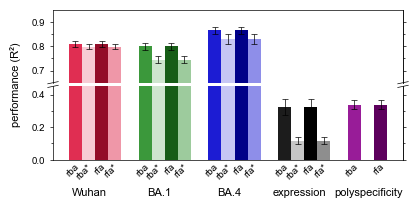

In [3]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

LINEWIDTH = 0.5

MAJOR_TICK_WID = 0.5
MINOR_TICK_WID = 0.5
MAJOR_TICK_LEN = 2
MINOR_TICK_LEN = 1.5

LABEL_FONTSIZE = 8
TICK_LABEL_FONTSIZE = 7

CANVAS_WIDTH  = 3.5
CANVAS_HEIGHT = 1.5

LEFT_MARGIN   = 0.6
RIGHT_MARGIN  = 0.2
TOP_MARGIN    = 0.2
BOTTOM_MARGIN = 0.9

BAR_WIDTH = 0.15
GROUP_GAP = 0.2

Y_LABEL_PAD = -0.1

BAR_LABEL_Y   = -0.015   
GROUP_LABEL_Y = -0.175  

BAR_LABEL_OFFSETS = {
    0: (0.06, 0),   # rba
    1: (0.06, 0),   # rba*
    2: (0.06, 0),   # rfa
    3: (0.06, 0),   # rfa*
}

GROUP_LABEL_OFFSETS = {
    'Wuhan':           (-0.06, 0),
    'BA.1':            (-0.06, 0),
    'BA.4':            (-0.06, 0),
    'expression':      (-0.06, 0),
    'polyspecificity': (-0.06, 0.005),
}

COLOR_WUHAN = "#DC143C"
COLOR_BA1   = "#228B22"
COLOR_BA4   = "#0000CD"
COLOR_EXPR  = "#000000"
COLOR_PSR   = "#8b008b"

def create_color_palette(base_color, n_colors=10):
    rgb = mcolors.hex2color(base_color)
    colors = []
    for i in range(n_colors):
        position = (i / (n_colors - 1)) * 2 - 1
        if position < 0:
            factor = 1 + position
            new_rgb = [c * factor for c in rgb]
        else:
            factor = position
            new_rgb = [c + (1 - c) * factor for c in rgb]
        colors.append(mcolors.rgb2hex(new_rgb))
    return colors

colors_wuhan      = create_color_palette(COLOR_WUHAN)
colors_ba1        = create_color_palette(COLOR_BA1)
colors_ba4        = create_color_palette(COLOR_BA4)
colors_expression = create_color_palette(COLOR_EXPR)
colors_psr        = create_color_palette(COLOR_PSR)

COLOR_INDICES = [5, 8, 3, 7]

file_configs = {
    'Wuhan': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/wuhan/reference-based/find_best_order_CVs/CV_summaries/wuhan_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/wuhan/reference-free/find_best_order_CVs/CV_summaries/wuhan_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
    },
    'BA.1': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/ba1/reference-based/find_best_order_CVs/CV_summaries/ba1_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     3,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/ba1/reference-free/find_best_order_CVs/CV_summaries/ba1_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     3,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
    },
    'BA.4': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/ba4/reference-based/find_best_order_CVs/CV_summaries/ba4_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     3,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/ba4/reference-free/find_best_order_CVs/CV_summaries/ba4_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     3,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
    },
    'expression': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/expression/reference-based/find_best_order_CVs/CV_summaries/expression_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    'latent_logistic_v1',
            'global_order':        2,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/expression/reference-free/find_best_order_CVs/CV_summaries/expression_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    'latent_logistic_v1',
            'global_order':        2,
        },
    },
    'polyspecificity': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/psr/reference-based/find_best_order_CVs/CV_summaries/psr_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    None,
            'global_order':        None,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/psr/reference-free/find_best_order_CVs/CV_summaries/psr_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    None,
            'global_order':        None,
        },
    },
}

phenotype_palettes = {
    'Wuhan':           colors_wuhan,
    'BA.1':            colors_ba1,
    'BA.4':            colors_ba4,
    'expression':      colors_expression,
    'polyspecificity': colors_psr,
}

phenotype_order = ['Wuhan', 'BA.1', 'BA.4', 'expression', 'polyspecificity']
model_labels    = ['rba', 'rba*', 'rfa', 'rfa*']

def load_r2(path, phenotype_val, order):
    if phenotype_val is None or order is None:
        return np.nan, np.nan

    df = pd.read_csv(path)
    df['order']        = pd.to_numeric(df['order'],        errors='coerce')
    df['r2_test_mean'] = pd.to_numeric(df['r2_test_mean'], errors='coerce')
    df['r2_test_std']  = pd.to_numeric(df['r2_test_std'],  errors='coerce')

    mask = (
        (df['phenotype_name'] == phenotype_val) &
        (df['scope']          == 'all') &
        (df['order']          == order)
    )
    row = df[mask]

    if len(row) == 0:
        print(f"WARNING: No data found for phenotype='{phenotype_val}', scope='all', order={order} in {path}")
        return np.nan, np.nan

    return row['r2_test_mean'].values[0], row['r2_test_std'].values[0]

plot_data = {}
for phenotype in phenotype_order:
    cfg = file_configs[phenotype]
    entries = [
        (False,
         load_r2(cfg['biochem']['path'],     cfg['biochem']['nonglobal_phenotype'],    cfg['biochem']['nonglobal_order'])),
        (cfg['biochem']['global_phenotype'] is None,
         load_r2(cfg['biochem']['path'],     cfg['biochem']['global_phenotype'],        cfg['biochem']['global_order'])),
        (False,
         load_r2(cfg['statistical']['path'], cfg['statistical']['nonglobal_phenotype'], cfg['statistical']['nonglobal_order'])),
        (cfg['statistical']['global_phenotype'] is None,
         load_r2(cfg['statistical']['path'], cfg['statistical']['global_phenotype'],    cfg['statistical']['global_order'])),
    ]
    plot_data[phenotype] = entries

n_models      = 4
group_width   = n_models * BAR_WIDTH + GROUP_GAP
group_centers = np.arange(len(phenotype_order)) * group_width
offsets       = (np.arange(n_models) - (n_models - 1) / 2) * BAR_WIDTH

fig_width  = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

fig = plt.figure(figsize=(fig_width, fig_height))

gs = GridSpec(2, 1, figure=fig,
              left   = LEFT_MARGIN / fig_width,
              right  = (LEFT_MARGIN + CANVAS_WIDTH) / fig_width,
              top    = 1 - TOP_MARGIN / fig_height,
              bottom = BOTTOM_MARGIN / fig_height,
              hspace = 0.05,
              height_ratios=[1, 1])

ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1])

for ax in [ax_top, ax_bottom]:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(LINEWIDTH)

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)

def add_right_ticks(ax, major_locs, minor_locs):
    ax_r = ax.twinx()
    ax_r.set_ylim(ax.get_ylim())
    ax_r.yaxis.set_major_locator(FixedLocator(major_locs))
    ax_r.yaxis.set_minor_locator(FixedLocator(minor_locs))
    ax_r.tick_params(axis='y', which='major',
                     width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                     direction='out', labelright=False)
    ax_r.tick_params(axis='y', which='minor',
                     width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
                     direction='out', labelright=False)
    for spine in ax_r.spines.values():
        spine.set_linewidth(LINEWIDTH)
    ax_r.spines['left'].set_visible(False)
    ax_r.spines['top'].set_visible(False)
    ax_r.spines['bottom'].set_visible(False)
    return ax_r

ax_top.set_ylim(0.65, 0.95)
ax_top.yaxis.set_major_locator(FixedLocator([0.7, 0.8, 0.9]))
ax_top.yaxis.set_minor_locator(FixedLocator([0.75, 0.85]))
ax_top.tick_params(axis='y', which='major',
                   width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                   direction='out', labelsize=TICK_LABEL_FONTSIZE)
ax_top.tick_params(axis='y', which='minor',
                   width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
                   direction='out', labelleft=False)
ax_top_r = add_right_ticks(ax_top,
                            major_locs=[0.7, 0.8, 0.9],
                            minor_locs=[0.75, 0.85])
ax_top_r.spines['top'].set_visible(False)

ax_bottom.set_ylim(0.0, 0.45)
ax_bottom.yaxis.set_major_locator(FixedLocator([0.0, 0.2, 0.4]))
ax_bottom.yaxis.set_minor_locator(FixedLocator([0.1, 0.3]))
ax_bottom.tick_params(axis='y', which='major',
                      width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                      direction='out', labelsize=TICK_LABEL_FONTSIZE)
ax_bottom.tick_params(axis='y', which='minor',
                      width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
                      direction='out', labelleft=False)
ax_bottom_r = add_right_ticks(ax_bottom,
                               major_locs=[0.0, 0.2, 0.4],
                               minor_locs=[0.1, 0.3])
ax_bottom_r.spines['bottom'].set_visible(False)

ax_top.set_xticks([])
ax_top.tick_params(axis='x', which='both', bottom=False)

ax_bottom.set_xticks([])
ax_bottom.set_xticklabels([])
ax_bottom.tick_params(axis='x', which='both', length=0)

def plot_bars(ax):
    for g, phenotype in enumerate(phenotype_order):
        palette = phenotype_palettes[phenotype]
        entries = plot_data[phenotype]
        for m, (skip, (mean, std)) in enumerate(entries):
            if skip:
                continue
            x     = group_centers[g] + offsets[m]
            color = palette[COLOR_INDICES[m]]
            ax.bar(x, mean, width=BAR_WIDTH,
                   color=color, edgecolor='none', linewidth=LINEWIDTH)
            if not np.isnan(mean) and not np.isnan(std):
                ax.errorbar(x, mean, yerr=std,
                            fmt='none', ecolor='black',
                            elinewidth=LINEWIDTH, capsize=2, capthick=LINEWIDTH)

plot_bars(ax_top)
plot_bars(ax_bottom)


for g, phenotype in enumerate(phenotype_order):
    entries = plot_data[phenotype]
    for m, (skip, _) in enumerate(entries):
        if skip:
            continue
        x = group_centers[g] + offsets[m]
        dx, dy = BAR_LABEL_OFFSETS[m]
        ax_bottom.text(
            x + dx,
            BAR_LABEL_Y + dy,
            model_labels[m],
            ha='right', va='top',
            fontsize=TICK_LABEL_FONTSIZE,
            rotation=45,
            transform=ax_bottom.transData,
            clip_on=False,
        )

for g, phenotype in enumerate(phenotype_order):
    dx, dy = GROUP_LABEL_OFFSETS[phenotype]
    ax_bottom.text(
        group_centers[g] + dx,
        GROUP_LABEL_Y + dy,
        phenotype,
        ha='center', va='top',
        fontsize=LABEL_FONTSIZE,
        transform=ax_bottom.transData,
        clip_on=False,
    )

d = 0.015
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=LINEWIDTH)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

fig.text(LEFT_MARGIN / fig_width + Y_LABEL_PAD,
         (BOTTOM_MARGIN + CANVAS_HEIGHT * 0.5) / fig_height,
         'performance (R²)',
         fontsize=LABEL_FONTSIZE, va='center', rotation='vertical')

plt.savefig('S_Figure_5e.png', dpi=2000, bbox_inches='tight', transparent=True)

plt.show()

**Supplemental Figure 5f**

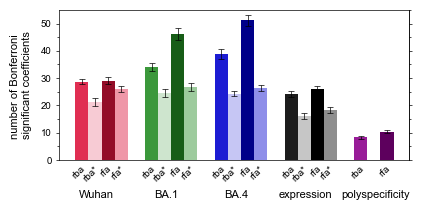

In [4]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

LINEWIDTH = 0.5

MAJOR_TICK_WID = 0.5
MINOR_TICK_WID = 0.5
MAJOR_TICK_LEN = 2
MINOR_TICK_LEN = 1.5

LABEL_FONTSIZE = 8
TICK_LABEL_FONTSIZE = 7

CANVAS_WIDTH  = 3.5
CANVAS_HEIGHT = 1.5

LEFT_MARGIN   = 0.6
RIGHT_MARGIN  = 0.2
TOP_MARGIN    = 0.2
BOTTOM_MARGIN = 0.9

BAR_WIDTH = 0.15
GROUP_GAP = 0.2

Y_LABEL_PAD = -0.115

BAR_LABEL_Y   = -1.5    
GROUP_LABEL_Y = -11   

BAR_LABEL_OFFSETS = {
    0: (0.06, 0),   # rba
    1: (0.06, 0),   # rba*
    2: (0.06, 0),   # rfa
    3: (0.06, 0),   # rfa*
}

GROUP_LABEL_OFFSETS = {
    'Wuhan':           (-0.06, 0),
    'BA.1':            (-0.06, 0),
    'BA.4':            (-0.06, 0),
    'expression':      (-0.06, 0),
    'polyspecificity': (-0.06, 0),
}

COLOR_WUHAN = "#DC143C"
COLOR_BA1   = "#228B22"
COLOR_BA4   = "#0000CD"
COLOR_EXPR  = "#000000"
COLOR_PSR   = "#8b008b"

def create_color_palette(base_color, n_colors=10):
    rgb = mcolors.hex2color(base_color)
    colors = []
    for i in range(n_colors):
        position = (i / (n_colors - 1)) * 2 - 1
        if position < 0:
            factor = 1 + position
            new_rgb = [c * factor for c in rgb]
        else:
            factor = position
            new_rgb = [c + (1 - c) * factor for c in rgb]
        colors.append(mcolors.rgb2hex(new_rgb))
    return colors

colors_wuhan      = create_color_palette(COLOR_WUHAN)
colors_ba1        = create_color_palette(COLOR_BA1)
colors_ba4        = create_color_palette(COLOR_BA4)
colors_expression = create_color_palette(COLOR_EXPR)
colors_psr        = create_color_palette(COLOR_PSR)

COLOR_INDICES = [5, 8, 3, 7]

file_configs = {
    'Wuhan': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/wuhan/reference-based/find_best_order_CVs/CV_summaries/wuhan_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/wuhan/reference-free/find_best_order_CVs/CV_summaries/wuhan_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
    },
    'BA.1': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/ba1/reference-based/find_best_order_CVs/CV_summaries/ba1_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     3,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/ba1/reference-free/find_best_order_CVs/CV_summaries/ba1_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     3,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
    },
    'BA.4': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/ba4/reference-based/find_best_order_CVs/CV_summaries/ba4_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     3,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/ba4/reference-free/find_best_order_CVs/CV_summaries/ba4_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     3,
            'global_phenotype':    'latent_hill_v1',
            'global_order':        2,
        },
    },
    'expression': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/expression/reference-based/find_best_order_CVs/CV_summaries/expression_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    'latent_logistic_v1',
            'global_order':        2,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/expression/reference-free/find_best_order_CVs/CV_summaries/expression_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    'latent_logistic_v1',
            'global_order':        2,
        },
    },
    'polyspecificity': {
        'biochem': {
            'path':                '../../epistasis_inference/linear_interaction_models/psr/reference-based/find_best_order_CVs/CV_summaries/psr_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    None,
            'global_order':        None,
        },
        'statistical': {
            'path':                '../../epistasis_inference/linear_interaction_models/psr/reference-free/find_best_order_CVs/CV_summaries/psr_globalep_model_comparison.csv',
            'nonglobal_phenotype': 'raw',
            'nonglobal_order':     2,
            'global_phenotype':    None,
            'global_order':        None,
        },
    },
}

phenotype_palettes = {
    'Wuhan':           colors_wuhan,
    'BA.1':            colors_ba1,
    'BA.4':            colors_ba4,
    'expression':      colors_expression,
    'polyspecificity': colors_psr,
}

phenotype_order = ['Wuhan', 'BA.1', 'BA.4', 'expression', 'polyspecificity']
model_labels    = ['rba', 'rba*', 'rfa', 'rfa*']

def load_num_sig(path, phenotype_val, order):
    if phenotype_val is None or order is None:
        return np.nan, np.nan

    df = pd.read_csv(path)
    df['order']        = pd.to_numeric(df['order'],        errors='coerce')
    df['num_sig_mean'] = pd.to_numeric(df['num_sig_mean'], errors='coerce')
    df['num_sig_std']  = pd.to_numeric(df['num_sig_std'],  errors='coerce')

    mask = (
        (df['phenotype_name'] == phenotype_val) &
        (df['scope']          == 'all') &
        (df['order']          == order)
    )
    row = df[mask]

    if len(row) == 0:
        print(f"WARNING: No data found for phenotype='{phenotype_val}', scope='all', order={order} in {path}")
        return np.nan, np.nan

    return row['num_sig_mean'].values[0], row['num_sig_std'].values[0]

plot_data = {}
for phenotype in phenotype_order:
    cfg = file_configs[phenotype]
    entries = [
        (False,
         load_num_sig(cfg['biochem']['path'],     cfg['biochem']['nonglobal_phenotype'],    cfg['biochem']['nonglobal_order'])),
        (cfg['biochem']['global_phenotype'] is None,
         load_num_sig(cfg['biochem']['path'],     cfg['biochem']['global_phenotype'],        cfg['biochem']['global_order'])),
        (False,
         load_num_sig(cfg['statistical']['path'], cfg['statistical']['nonglobal_phenotype'], cfg['statistical']['nonglobal_order'])),
        (cfg['statistical']['global_phenotype'] is None,
         load_num_sig(cfg['statistical']['path'], cfg['statistical']['global_phenotype'],    cfg['statistical']['global_order'])),
    ]
    plot_data[phenotype] = entries

n_models      = 4
group_width   = n_models * BAR_WIDTH + GROUP_GAP
group_centers = np.arange(len(phenotype_order)) * group_width
offsets       = (np.arange(n_models) - (n_models - 1) / 2) * BAR_WIDTH

fig_width  = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

fig = plt.figure(figsize=(fig_width, fig_height))

gs = GridSpec(1, 1, figure=fig,
              left   = LEFT_MARGIN / fig_width,
              right  = (LEFT_MARGIN + CANVAS_WIDTH) / fig_width,
              top    = 1 - TOP_MARGIN / fig_height,
              bottom = BOTTOM_MARGIN / fig_height)

ax = fig.add_subplot(gs[0])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(LINEWIDTH)

ax.set_ylim(0, 55)
ax.yaxis.set_major_locator(FixedLocator([0, 10, 20, 30, 40, 50]))
ax.yaxis.set_minor_locator(FixedLocator([5, 15, 25, 35, 45]))
ax.tick_params(axis='y', which='major',
               width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
               direction='out', labelsize=TICK_LABEL_FONTSIZE)
ax.tick_params(axis='y', which='minor',
               width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
               direction='out', labelleft=False)

ax_r = ax.twinx()
ax_r.set_ylim(ax.get_ylim())
ax_r.yaxis.set_major_locator(FixedLocator([0, 10, 20, 30, 40, 50]))
ax_r.yaxis.set_minor_locator(FixedLocator([5, 15, 25, 35, 45, 55]))
ax_r.tick_params(axis='y', which='major',
                 width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                 direction='out', labelright=False)
ax_r.tick_params(axis='y', which='minor',
                 width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
                 direction='out', labelright=False)
for spine in ax_r.spines.values():
    spine.set_linewidth(LINEWIDTH)
ax_r.spines['top'].set_visible(False)
ax_r.spines['bottom'].set_visible(False)
ax_r.spines['left'].set_visible(False)

ax.set_xticks([])
ax.tick_params(axis='x', which='both', length=0)

for g, phenotype in enumerate(phenotype_order):
    palette = phenotype_palettes[phenotype]
    entries = plot_data[phenotype]
    for m, (skip, (mean, std)) in enumerate(entries):
        if skip:
            continue
        x     = group_centers[g] + offsets[m]
        color = palette[COLOR_INDICES[m]]
        ax.bar(x, mean, width=BAR_WIDTH,
               color=color, edgecolor='none', linewidth=LINEWIDTH)
        if not np.isnan(mean) and not np.isnan(std):
            ax.errorbar(x, mean, yerr=std,
                        fmt='none', ecolor='black',
                        elinewidth=LINEWIDTH, capsize=2, capthick=LINEWIDTH)

for g, phenotype in enumerate(phenotype_order):
    entries = plot_data[phenotype]
    for m, (skip, _) in enumerate(entries):
        if skip:
            continue
        x = group_centers[g] + offsets[m]
        dx, dy = BAR_LABEL_OFFSETS[m]
        ax.text(
            x + dx,
            BAR_LABEL_Y + dy,
            model_labels[m],
            ha='right', va='top',
            fontsize=TICK_LABEL_FONTSIZE,
            rotation=45,
            transform=ax.transData,
            clip_on=False,
        )

for g, phenotype in enumerate(phenotype_order):
    dx, dy = GROUP_LABEL_OFFSETS[phenotype]
    ax.text(
        group_centers[g] + dx,
        GROUP_LABEL_Y + dy,
        phenotype,
        ha='center', va='top',
        fontsize=LABEL_FONTSIZE,
        transform=ax.transData,
        clip_on=False,
    )

fig.text(LEFT_MARGIN / fig_width + Y_LABEL_PAD,
         (BOTTOM_MARGIN + CANVAS_HEIGHT * 0.5) / fig_height,
         'number of Bonferroni\nsignificant coefficients',
         fontsize=LABEL_FONTSIZE, va='center', rotation='vertical')

plt.savefig('S_Figure_5f.png', dpi=2000, bbox_inches='tight', transparent=True)

plt.show()